Dataset shape: (5169, 2)

Label distribution:
label
ham     4516
spam     653
Name: count, dtype: int64

Label distribution (%):
label
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64

Average length by class:
label
ham      70.459256
spam    137.891271
Name: text_length, dtype: float64

Training samples: 4135
Testing samples:  1034

Vocabulary size: 5000

=== Multinomial Naive Bayes ===
Accuracy:  0.9662
Precision: 0.9898
Recall:    0.7405
F1-score:  0.8472
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       903
        spam       0.99      0.74      0.85       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.91      1034
weighted avg       0.97      0.97      0.96      1034


=== Logistic Regression ===
Accuracy:  0.9536
Precision: 0.9770
Recall:    0.6489
F1-score:  0.7798
              precision    recall  f1-score   support

         ham       0.95      1.00 

/Users/swapnalatha/Downloads/Data-Science/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/swapnalatha/Downloads/Data-Science/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: overflow encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/swapnalatha/Downloads/Data-Science/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: invalid value encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)


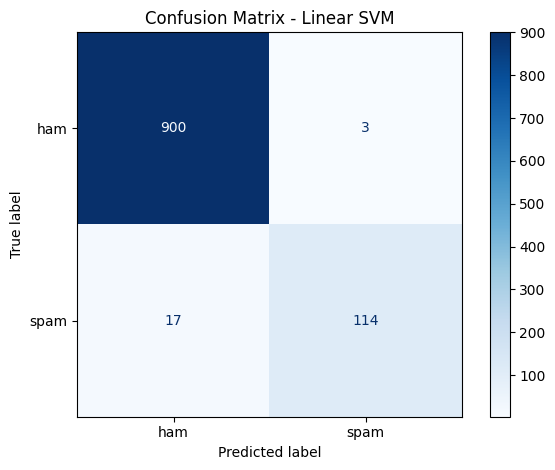

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

df = pd.read_csv("spam.csv", encoding="latin-1")

df = df[["v1", "v2"]]
df.columns = ["label", "text"]

df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape:", df.shape)
print("\nLabel distribution:")
print(df["label"].value_counts())
print("\nLabel distribution (%):")
print(df["label"].value_counts(normalize=True) * 100)


def clean_text(text):
    """Lowercase, remove non-alphabetic characters, collapse whitespace."""
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)

df["text_length"] = df["text"].apply(len)

print("\nAverage length by class:")
print(df.groupby("label")["text_length"].mean())

df["label_num"] = df["label"].map({"ham": 0, "spam": 1})


X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["label_num"],
    test_size=0.2,
    random_state=42,
    stratify=df["label_num"],
)

print(f"\nTraining samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2),
)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"\nVocabulary size: {len(vectorizer.vocabulary_)}")

models = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(),
}

results = {}

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[name] = {
        "model": model,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "y_pred": y_pred,
    }

    print(f"\n=== {name} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=["ham", "spam"]))

best_name = max(results, key=lambda k: results[k]["f1"])
best_model = results[best_name]["model"]
print(f"\nBest model based on F1-score: {best_name}")

cm = confusion_matrix(y_test, results[best_name]["y_pred"])
print(f"\nConfusion Matrix for {best_name}:\n{cm}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["ham", "spam"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix - {best_name}")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
print("\nConfusion matrix plot saved as 'confusion_matrix.png'")

def predict_messages(messages, model=best_model, vectorizer=vectorizer):
    """
    Predict whether each message in `messages` (list of strings) is spam or ham.
    Returns a list of dicts with the message, predicted label, and
    (if available) the spam probability.
    """
    cleaned = [clean_text(m) for m in messages]
    vec = vectorizer.transform(cleaned)
    preds = model.predict(vec)

    output = []
    for msg, pred in zip(messages, preds):
        result = {"message": msg, "prediction": "spam" if pred == 1 else "ham"}

        # If the model supports probability estimates, include them
        if hasattr(model, "predict_proba"):
            proba = model.predict_proba(vectorizer.transform([clean_text(msg)]))[0]
            result["spam_probability"] = round(proba[1], 4)

        output.append(result)
    return output

sample_messages = [
    "Congratulations! You've won a $1000 Walmart gift card. Click here to claim now!",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT: Your account has been suspended. Verify your details immediately.",
    "Can you send me the report by EOD?",
    "WINNER!! As a valued network customer you have been selected to receive a prize.",
]

print("\n=== Sample Predictions ===")
for r in predict_messages(sample_messages):
    if "spam_probability" in r:
        print(f"[{r['prediction'].upper():5s}] ({r['spam_probability']*100:.1f}% spam) {r['message']}")
    else:
        print(f"[{r['prediction'].upper():5s}] {r['message']}")